In [58]:
from CountsinCylinders import *
from astropy.table import Table, vstack
from astropy.table import vstack
import fitsio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from math import log10, floor
import CiCPlot

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
from importlib import reload

In [59]:
#general parameters
R_CiC = 0.1 #radius in Mpc
L_CiC = 15 #height of cylinder in Mpc
zlim = [0.8,1]
psilim = [0.2,1.5]

In [60]:
#loadholes
holetableselg = []
holetableslrg = []
for i in range(117):
    spelg = Table.read("datafiles/Holes_ELG_SV3_tile"+str(i)+"_holes.csv",format = "csv")
    splrg = Table.read("datafiles/Holes_LRG_SV3_tile"+str(i)+"_holes.csv",format = "csv")
    holetableselg.append(spelg)
    holetableslrg.append(splrg)
holetableelg = vstack(holetableselg)
holetablelrg = vstack(holetableslrg)
print(len(holetableelg),len(holetablelrg))

4646361 4697603


In [61]:
#SV3 CiC, 22 September 2026

file_elgS = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/ELG_HIPnotqso_S_clustering.dat.fits'#'/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/ELG_HIPnotqso_S_clustering.dat.fits'
file_elgN = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/ELG_HIPnotqso_N_clustering.dat.fits'#'/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/ELG_HIPnotqso_N_clustering.dat.fits'
file_lrgS = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/LRG_main_S_clustering.dat.fits'
file_lrgN = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/LRG_main_N_clustering.dat.fits'
columns = ['RA','DEC','Z']
columnnames = columns[:3]
sp1 = Table(fitsio.read(file_elgN, columns=columns))
sp2 = Table(fitsio.read(file_elgS, columns=columns))
sp3 = Table(fitsio.read(file_lrgN, columns=columns))
sp4 = Table(fitsio.read(file_lrgS, columns=columns))
spE = vstack([sp1,sp2])
spL = vstack([sp3,sp4])
spelg = spE[(spE["Z"] > zlim[0])&(spE["Z"] < zlim[1])]
splrg = spL[(spL["Z"] > zlim[0])&(spL["Z"] < zlim[1])]

primarymask = makePrimariesRosettes
primaryargs = [*zlim,*psilim,R_CiC,L_CiC,'RA','DEC']

outfilename = "SV3_z0.8_1.6_R"+str(R_CiC)+"L"+str(R_CiC)

In [62]:

R_hole = 0.03*np.pi/180 #convert from degrees to radians
countsInCylindersHoleClean(spelg, splrg, holetableelg,holetablelrg,columnnames, R_CiC, L_CiC,R_hole, zlim, primarymask, primaryargs, outfilename)
#countsInCylinders(spelg, splrg, columnnames, R_CiC, L_CiC, zlim, primarymask, primaryargs, outfilename, secondarymask = makePrimariesRosettesNoZBoundary,secondaryargs=primaryargs)

finding unit sphere coordinates of galaxies
finding Cartesian coordinates of galaxies
making cKDTrees
eliminating galaxies near holes
initial ELGs: 44414
initial primary LRGs: 23567
finished hole cleaning
ELG primaries remaining: 39837
LRG primaries remaining: 20737
Pass rate, ELGs: 0.8969469086324132
Pass rate, LRGs: 0.879916832859507
Searching for neighbors in spheres
Pruning galaxies from spheres
Pruning ELG auto-correlation
   Galaxy 0
Pruning LRG auto-correlation
   Galaxy 0
Pruning ELG-LRG cross-correlation
   Galaxy 0
Pruning LRG-ELG cross-correlation
   Galaxy 0
Saved file datafiles/SV3_z0.8_1.6_R0.1L40_elg.csv
Saved file datafiles/SV3_z0.8_1.6_R0.1L40_lrg.csv


In [63]:
#general parameters
R_CiC = 0.2 #radius in Mpc
L_CiC = 40 #height of cylinder in Mpc
zlim = [0.8,1]
psilim = [0.2,1.5]

In [64]:
outfilename = "SV3_z0.8_1.6_R"+str(R_CiC)+"L"+str(R_CiC)
R_hole = 0.03*np.pi/180 #convert from degrees to radians
countsInCylindersHoleClean(spelg, splrg, holetableelg,holetablelrg,columnnames, R_CiC, L_CiC,R_hole, zlim, primarymask, primaryargs, outfilename)
#countsInCylinders(spelg, splrg, columnnames, R_CiC, L_CiC, zlim, primarymask, primaryargs, outfilename, secondarymask = makePrimariesRosettesNoZBoundary,secondaryargs=primaryargs)

finding unit sphere coordinates of galaxies
finding Cartesian coordinates of galaxies
making cKDTrees
eliminating galaxies near holes
initial ELGs: 44414
initial primary LRGs: 23567
finished hole cleaning
ELG primaries remaining: 39837
LRG primaries remaining: 20737
Pass rate, ELGs: 0.8969469086324132
Pass rate, LRGs: 0.879916832859507
Searching for neighbors in spheres
Pruning galaxies from spheres
Pruning ELG auto-correlation
   Galaxy 0
Pruning LRG auto-correlation
   Galaxy 0
Pruning ELG-LRG cross-correlation
   Galaxy 0
Pruning LRG-ELG cross-correlation
   Galaxy 0
Saved file datafiles/SV3_z0.8_1.6_R0.2L40_elg.csv
Saved file datafiles/SV3_z0.8_1.6_R0.2L40_lrg.csv


### Plots counts-in-cylinders distributions ###

In [71]:
sv3elg0_1 = Table.read("datafiles/SV3_z0.8_1.6_R0.1L40_elg.csv")
sv3lrg0_1 = Table.read("datafiles/SV3_z0.8_1.6_R0.1L40_lrg.csv")

sv3elg0_1_ros = [sv3elg0_1[(sv3elg0_1['rosette'] == i)] for i in np.arange(1,21)]
sv3lrg0_1_ros = [sv3lrg0_1[(sv3lrg0_1['rosette'] == i)] for i in np.arange(1,21)]

sv3elg0_2 = Table.read("datafiles/SV3_z0.8_1.6_R0.2L40_elg.csv")
sv3lrg0_2 = Table.read("datafiles/SV3_z0.8_1.6_R0.2L40_lrg.csv")

sv3elg0_2_ros = [sv3elg0_2[(sv3elg0_2['rosette'] == i)] for i in np.arange(1,21)]
sv3lrg0_2_ros = [sv3lrg0_2[(sv3lrg0_2['rosette'] == i)] for i in np.arange(1,21)]

In [72]:
binmax = 6
histsv30_1 = CiCPlot.jackknifeCiCError(sv3elg0_1_ros,sv3lrg0_1_ros,binmax)

binmax = 6
histsv30_2 = CiCPlot.jackknifeCiCError(sv3elg0_2_ros,sv3lrg0_2_ros,binmax)

Text(0.5, 1.0, 'Counts in Cylinders in SV3, $R_{CiC} = 100$ kpc (1.4 kpc/h), $L_{CiC} = 15$ Mpc (10.5 Mpc/h)')

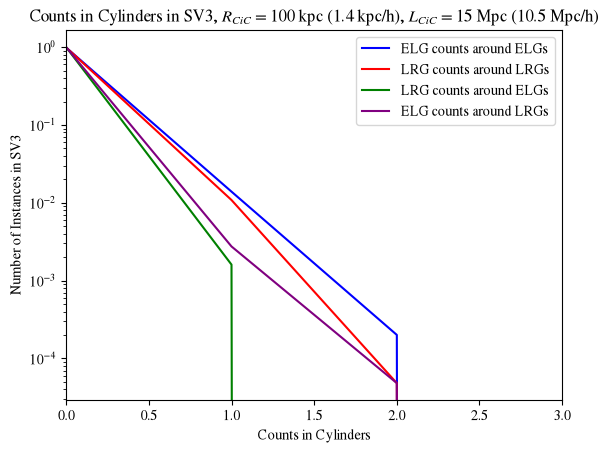

In [87]:
'''bins = np.arange(binmax)
plt.plot(bins,np.sum(histsv30_1.elghist_nodens,axis=0),label="ELG counts around ELGs",color='blue')
plt.yscale('log')
plt.plot(bins,np.sum(histsv30_1.lrghist_nodens,axis=0),label="LRG counts around LRGs",color='red')

plt.plot(bins,np.sum(histsv30_1.elglrghist_nodens,axis=0),label="LRG counts around ELGs",color='green')
plt.yscale('log')
plt.plot(bins,np.sum(histsv30_1.lrgelghist_nodens,axis=0),label="ELG counts around LRGs",color='purple')
plt.legend()
plt.xlim(0,3)

plt.xlabel("Counts in Cylinders")
plt.ylabel("Number of Instances in SV3")
plt.title(r"Counts in Cylinders in SV3, $R_{CiC} = 200$ kpc (1.4 kpc/h), $L_{CiC} = 15$ Mpc (10.5 Mpc/h))")
plt.savefig("figs/SV3R0_1.png")'''

bins = np.arange(binmax)
plt.plot(bins,histsv30_1.elghistcomb,label="ELG counts around ELGs",color='blue')
plt.yscale('log')
plt.plot(bins,histsv30_1.lrghistcomb,label="LRG counts around LRGs",color='red')

plt.plot(bins,histsv30_1.elglrghistcomb,label="LRG counts around ELGs",color='green')
plt.yscale('log')
plt.plot(bins,histsv30_1.lrgelghistcomb,label="ELG counts around LRGs",color='purple')
plt.legend()
plt.xlim(0,3)

plt.xlabel("Counts in Cylinders")
plt.ylabel("Number of Instances in SV3")
plt.title(r"Counts in Cylinders in SV3, $R_{CiC} = 100$ kpc (1.4 kpc/h), $L_{CiC} = 15$ Mpc (10.5 Mpc/h)")
#plt.savefig("figs/SV3R0_1.png")

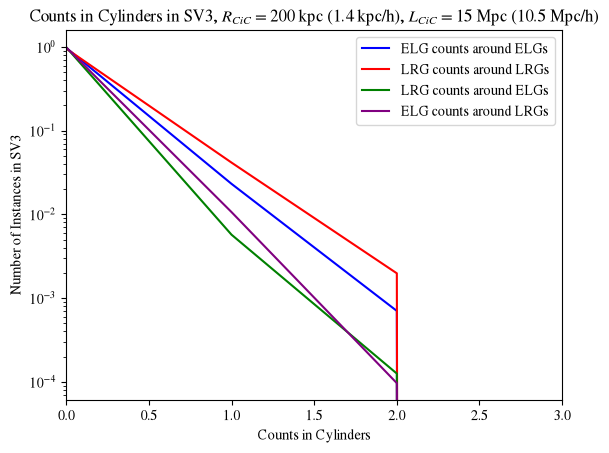

In [88]:
bins = np.arange(binmax)
plt.plot(bins,histsv30_2.elghistcomb,label="ELG counts around ELGs",color='blue')
plt.yscale('log')
plt.plot(bins,histsv30_2.lrghistcomb,label="LRG counts around LRGs",color='red')

plt.plot(bins,histsv30_2.elglrghistcomb,label="LRG counts around ELGs",color='green')
plt.yscale('log')
plt.plot(bins,histsv30_2.lrgelghistcomb,label="ELG counts around LRGs",color='purple')
plt.legend()
plt.xlim(0,3)

plt.xlabel("Counts in Cylinders")
plt.ylabel("Number of Instances in SV3")
plt.title(r"Counts in Cylinders in SV3, $R_{CiC} = 200$ kpc (1.4 kpc/h), $L_{CiC} = 15$ Mpc (10.5 Mpc/h)")
plt.savefig("figs/SV3R0_2.png")

In [78]:
print(histsv30_1.elghistcomb)
print(histsv30_2.lrghistcomb)

[9.85892512e-01 1.39066697e-02 2.00818335e-04 0.00000000e+00
 0.00000000e+00 0.00000000e+00]
[0.95645465 0.04156821 0.00197714 0.         0.         0.        ]


In [79]:
print("R = 100 kpc")
print("Probability of ELG having one ELG neighbor:")
print(np.round(100*histsv30_1.elghistcomb[1],1),"%")
print("Probability of ELG having one LRG neighbor:")
print(np.round(100*histsv30_1.elglrghistcomb[1],1),"%")
print("Probability of LRG having one LRG neighbor:")
print(np.round(100*histsv30_1.lrghistcomb[1],1),"%")
print("Probability of LRG having one ELG neighbor:")
print(np.round(100*histsv30_1.lrgelghistcomb[1],1),"%")

print("\nR = 200 kpc")
print("Probability of ELG having one ELG neighbor:")
print(np.round(100*histsv30_2.elghistcomb[1],1),"%")
print("Probability of ELG having one LRG neighbor:")
print(np.round(100*histsv30_2.elglrghistcomb[1],1),"%")
print("Probability of LRG having one LRG neighbor:")
print(np.round(100*histsv30_2.lrghistcomb[1],1),"%")
print("Probability of LRG having one ELG neighbor:")
print(np.round(100*histsv30_2.lrgelghistcomb[1],1),"%")

R = 100 kpc
Probability of ELG having one ELG neighbor:
1.4 %
Probability of ELG having one LRG neighbor:
0.2 %
Probability of LRG having one LRG neighbor:
1.1 %
Probability of LRG having one ELG neighbor:
0.3 %

R = 200 kpc
Probability of ELG having one ELG neighbor:
2.3 %
Probability of ELG having one LRG neighbor:
0.6 %
Probability of LRG having one LRG neighbor:
4.2 %
Probability of LRG having one ELG neighbor:
1.1 %
